In [69]:
import pandas as pd

# Input prep

In [138]:
data_raw = pd.read_excel('./CPL MEL8 1E6 MEL5 and 4C6.xlsx')#['MEL5 MIP1𝜷']
data_raw

,SubLibrary,Sequence,MEL8 MIP1𝜷,1E6 MIP1𝜷,MEL5 MIP1𝜷,4C6 MIP1𝜷
0,1A,AXXXXXXXXX,1423.61,302.741117,519.6,122.93370
1,1C,CXXXXXXXXX,616.71,1812.791878,58.8,191.23020
2,1D,DXXXXXXXXX,515.16,-123.045685,68.4,314.16390
3,1E,EXXXXXXXXX,319.43,-22.538071,85.2,221.28066
4,1F,FXXXXXXXXX,204.95,70.659898,2091.6,37.33542
...,...,...,...,...,...,...
195,10S,XXXXXXXXXS,302.82,-37.157361,246.0,NaN
196,10T,XXXXXXXXXT,775.50,854.010152,594.0,NaN
197,10V,XXXXXXXXXV,865.98,2156.954315,1108.8,NaN
198,10W,XXXXXXXXXW,-29.54,-98.680203,147.6,NaN


In [139]:
data_raw['residue'] = data_raw.SubLibrary.apply(lambda x: x[-1])
data_raw['position'] = data_raw.SubLibrary.apply(lambda x: int(x[0]) if len(x) == 2 else int(x[:2]))
data_raw

,SubLibrary,Sequence,MEL8 MIP1𝜷,1E6 MIP1𝜷,MEL5 MIP1𝜷,4C6 MIP1𝜷,residue,position
0,1A,AXXXXXXXXX,1423.61,302.741117,519.6,122.93370,A,1
1,1C,CXXXXXXXXX,616.71,1812.791878,58.8,191.23020,C,1
2,1D,DXXXXXXXXX,515.16,-123.045685,68.4,314.16390,D,1
3,1E,EXXXXXXXXX,319.43,-22.538071,85.2,221.28066,E,1
4,1F,FXXXXXXXXX,204.95,70.659898,2091.6,37.33542,F,1
...,...,...,...,...,...,...,...,...
195,10S,XXXXXXXXXS,302.82,-37.157361,246.0,NaN,S,10
196,10T,XXXXXXXXXT,775.50,854.010152,594.0,NaN,T,10
197,10V,XXXXXXXXXV,865.98,2156.954315,1108.8,NaN,V,10
198,10W,XXXXXXXXXW,-29.54,-98.680203,147.6,NaN,W,10


In [140]:
tcr_to_analyze = 'MEL5 MIP1𝜷'

data_cpl = data_raw.pivot(index='position', columns='residue', values=tcr_to_analyze)
data_cpl

residue,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
position,,,,,,,,,,,,,,,,,,,,
1,519.6,58.8,6.840000e+01,85.2,2091.6,746.4,948.0,1092.0,88.8,1591.2,1700.4,157.2,-49.2,0.0,-13.2,202.8,188.4,81.6,451.2,106.8
2,1142.4,88.8,5.280000e+01,80.4,590.4,814.8,139.2,710.4,354.0,1287.6,246.0,55.2,206.4,1039.2,97.2,886.8,1556.4,807.6,162.0,55.2
3,1783.2,133.2,1.020000e+02,525.6,-32.4,88.8,6.0,157.2,-4.8,307.2,46.8,138.0,373.2,1.2,50.4,1000.8,1671.6,12.0,762.0,12.0
4,890.4,134.4,-3.840000e+01,-15.6,44.4,1725.6,69.6,75.6,94.8,198.0,56.4,108.0,748.8,55.2,150.0,208.8,55.2,103.2,-4.8,75.6
5,120.0,-9.6,-1.705300e-14,46.8,42.0,130.8,56.4,1719.6,115.2,518.4,199.2,78.0,69.6,66.0,78.0,74.4,231.6,13.2,91.2,92.4
6,62.4,63.6,-2.400000e+00,-4.8,934.8,1599.6,98.4,39.6,192.0,44.4,30.0,56.4,294.0,76.8,102.0,127.2,15.6,18.0,756.0,1.2
7,32.4,61.2,1.200000e+01,31.2,108.0,134.4,54.0,1465.2,92.4,358.8,157.2,6.0,102.0,60.0,92.4,110.4,142.8,1322.4,28.8,409.2
8,398.4,75.6,3.720000e+01,28.8,110.4,272.4,199.2,1486.8,1267.2,751.2,1148.4,28.8,-9.6,22.8,214.8,283.2,224.4,1441.2,538.8,849.6
9,1056.0,140.4,5.880000e+01,10.8,226.8,90.0,50.4,786.0,1392.0,88.8,68.4,52.8,1405.2,94.8,1021.2,385.2,819.6,1323.6,85.2,21.6


In [141]:
best_aas = []

for _, position in data_cpl.iterrows():
    proper_variants = set(position[position > 500].index)
    if len(proper_variants) > 1:
        proper_variants = set(position.sort_values().tail(2).index)
    best_aas.append(proper_variants)

In [74]:
best_aas

[{'C', 'R'},
 {'L', 'Q'},
 {'F', 'W'},
 {'G'},
 {'P'},
 {'D', 'F'},
 {'F', 'W'},
 {'K', 'P'},
 {'I', 'T'},
 {'I', 'V'}]

In [75]:
best_aas[1] = set(['L', 'I', 'M'])
best_aas[8] = set(['V'])

import itertools

# The input list of sets
input_sets = best_aas

# Prepare options: replace empty sets with ['G'], and sort non-empty sets for consistent order
options = []
for s in input_sets:
    if not s:
        options.append(['G'])
    else:
        options.append(sorted(list(s)))

# Compute the Cartesian product
product_tuples = itertools.product(*options)

# Convert each tuple to a string
result_strings = [''.join(t) for t in product_tuples]

len(result_strings)

192

In [76]:
import random
random.shuffle(result_strings)

result_strings_to_generate = result_strings[0:160]


In [130]:
vdjdb = pd.read_csv('../vdjdb_full.txt', sep='\t')
data_cdr3 = vdjdb[vdjdb['meta.structure.id'] == '3hg1'].iloc[0]
data_cdr3

Columns (16,19,20,21,22,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.


cdr3.alpha                                                     CAVNVAGKSTF
v.alpha                                                        TRAV12-2*01
j.alpha                                                          TRAJ27*01
cdr3.beta                                                  CAWSETGLGTGELFF
v.beta                                                           TRBV30*01
d.beta                                                                 NaN
j.beta                                                          TRBJ2-2*01
species                                                        HomoSapiens
mhc.a                                                       HLA-A*02:01:48
mhc.b                                                                  B2M
mhc.class                                                             MHCI
antigen.epitope                                                 ELAGIGILTV
antigen.gene                                                         MLANA
antigen.species          

In [80]:
trav = data_cdr3['v.alpha']
traj = data_cdr3['j.alpha']
cdr3alpha = data_cdr3['cdr3.alpha']

trbv = data_cdr3['v.beta']
trbj = data_cdr3['j.beta']
cdr3beta = data_cdr3['cdr3.beta']

hla = 'HLA-A*02:01'
index_peptides = ['ALWGPDPAAA']

result_strings_to_generate = result_strings_to_generate + index_peptides

In [81]:
model_df = pd.DataFrame(result_strings_to_generate)
model_df['cdr3.alpha'] = cdr3alpha
model_df['cdr3.beta'] = cdr3beta

model_df['v.beta'] = trbv
model_df['j.beta'] = trbj

model_df['v.alpha'] = trav
model_df['j.alpha'] = traj

model_df['mhc.alpha'] = hla
model_df.rename(columns = {0: 'peptide'}, inplace=True)

In [82]:
from Stitchr import stitchrfunctions as fxn
from Stitchr import stitchr as st

from Bio.Seq import Seq

def get_aa_seq_cdr3(v, j, cdr3, chain):
    
    chain = chain
    species = 'HUMAN'

    # initialise the necessary data
    tcr_dat, functionality, partial = fxn.get_ref_data(chain, st.gene_types, species)
    codons = fxn.get_optimal_codons('', species)
    j_res, low_conf_js = fxn.get_j_motifs(species)
    c_res = fxn.get_c_motifs(species)
    
    c = 'TRBC1*01' if chain == 'TRB' else 'TRAC*01'
    # provide details of the rearrangement to be stitched
    tcr_bits = {'v': v, 'j': j, 'cdr3': cdr3,
                'l': v, 'c': c, 'mode': '',
                'skip_c_checks': False, 'skip_n_checks': False, 'no_leader': False,
                'species': species, 'seamless': False,
                '5_prime_seq': '', '3_prime_seq': '', 'name': 'my-cool-TCR'}

    # then run stitchr on that rearrangement
    stitched = st.stitch(tcr_bits, tcr_dat, functionality, partial, codons, 3, '',
                         c_res, j_res, low_conf_js)

    res_aa = str(Seq(stitched['stitched_nt']).translate())
    
    return res_aa

In [83]:
res_dict = {}

for clone_id, clone in model_df.iterrows():
    
    try:
        res_dict[clone_id] = {'TRA_aa_seq': get_aa_seq_cdr3(
            clone['v.alpha'],
            clone['j.alpha'],
            clone['cdr3.alpha'],
            'TRA'
                                                    ),
            'TRB_aa_seq': get_aa_seq_cdr3(
            clone['v.beta'],
            clone['j.beta'],
            clone['cdr3.beta'],
            'TRB')
                             }
    except:
        pass

In [84]:
motif_input_data = pd.concat([model_df, pd.DataFrame(res_dict).T], axis=1)

motif_input_data

,peptide,cdr3.alpha,cdr3.beta,v.beta,j.beta,v.alpha,j.alpha,mhc.alpha,TRA_aa_seq,TRB_aa_seq
0,RIWGPFWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
1,RLFGPFWKVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
2,RMFGPFFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
3,RIWGPDFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
4,RMFGPDWKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
...,...,...,...,...,...,...,...,...,...,...
156,RLFGPDFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
157,CMFGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
158,RMWGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...
159,RMFGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...


In [85]:
motif_input_data.rename(columns = {'mhc.alpha': 'mhc.a'}, inplace = True)
motif_input_data['mhc.b'] = 'B2M'

hla_data = pd.read_csv('/home/dluppov/tcrmodel_scripts/hla_table_full.tsv', sep='\t')
hla_data['proteine_type_allele'] = hla_data.allele.apply(lambda x: 'HLA-'+':'.join(x.split(':')[0:2]))
hla_data['allele_subtype'] = hla_data['proteine_type_allele'].apply(lambda x: x.split(':')[0])
hla_dict = hla_data.set_index('proteine_type_allele')['hla_aa_seq'].to_dict()

hla_dict['B2M'] = 'MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWVSSIRH'

motif_input_data['mhc.a.short'] = motif_input_data['mhc.a'].apply(lambda x: ':'.join(x.split(':')[0:2]))

motif_input_data['mhc.b.short'] = motif_input_data['mhc.b'].apply(lambda x: ':'.join(x.split(':')[0:2]) if x != 'B2M' else 'B2M')


motif_input_data['mhc.a.aa.seq'] = motif_input_data['mhc.a.short'].apply(lambda x: hla_dict.get(x))
motif_input_data['mhc.b.aa.seq'] = motif_input_data['mhc.b.short'].apply(lambda x: hla_dict.get(x))

In [86]:
motif_input_data.peptide.value_counts()

peptide
ALWGPDPAAA    1
RMWGPDWPVI    1
CMFGPDFPVI    1
CIFGPDWPVI    1
CLFGPFFKVV    1
             ..
RMFGPDWKVI    1
RIFGPFFPVI    1
CMWGPDWKVV    1
CMFGPFWPVI    1
CLFGPFWKVI    1
Name: count, Length: 161, dtype: int64

In [87]:
motif_input_data

,peptide,cdr3.alpha,cdr3.beta,v.beta,j.beta,v.alpha,j.alpha,mhc.a,TRA_aa_seq,TRB_aa_seq,mhc.b,mhc.a.short,mhc.b.short,mhc.a.aa.seq,mhc.b.aa.seq
0,RIWGPFWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
1,RLFGPFWKVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
2,RMFGPFFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
3,RIWGPDFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
4,RMFGPDWKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,RLFGPDFKVI,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
157,CMFGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
158,RMWGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...
159,RMFGPDWPVV,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF,TRBV12-4*01,TRBJ2-4*01,TRAV12-3*01,TRAJ12*01,HLA-A*02:01,MMKSLRVLLVILWLQLSWVWSQQKEVEQDPGPLSVPEGAIVSLNCT...,MGSWTLCCVSLCILVAKHTDAGVIQSPRHEVTEMGQEVTLRCKPIS...,B2M,HLA-A*02:01,B2M,MAVMAPRTLVLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...,MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWV...


In [88]:
motif_input_data.head(82).to_csv('peptide_swap_modeling_1e6_1.tsv', sep='\t')
motif_input_data.tail(82).to_csv('peptide_swap_modeling_1e6_2.tsv', sep='\t')

# Worst peptides analysis

In [34]:
best_aas = []

for _, position in data_cpl.iterrows():
    proper_variants = set(position[position < 100].index)
    if len(proper_variants) > 1:
        proper_variants = set(position.sort_values().head(2).index)
    if len(proper_variants) < 1:
        proper_variants = set(position.sort_values().head(1).index)
        
    best_aas.append(proper_variants)
    
best_aas[1] = set(['L', 'I', 'M'])
best_aas[8] = set(['V'])

import itertools

# The input list of sets
input_sets = best_aas

# Prepare options: replace empty sets with ['G'], and sort non-empty sets for consistent order
options = []
for s in input_sets:
    if not s:
        options.append(['G'])
    else:
        options.append(sorted(list(s)))

# Compute the Cartesian product
product_tuples = itertools.product(*options)

# Convert each tuple to a string
result_strings = [''.join(t) for t in product_tuples]
random.shuffle(result_strings)

len(result_strings)

768

In [35]:
model_df = pd.DataFrame(result_strings)
model_df['cdr3.alpha'] = cdr3alpha
model_df['cdr3.beta'] = cdr3beta

model_df['v.beta'] = trbv
model_df['j.beta'] = trbj

model_df['v.alpha'] = trav
model_df['j.alpha'] = traj

model_df['mhc.alpha'] = hla
model_df.rename(columns = {0: 'peptide'}, inplace=True)

res_dict = {}

for clone_id, clone in model_df.iterrows():
    
    try:
        res_dict[clone_id] = {'TRA_aa_seq': get_aa_seq_cdr3(
            clone['v.alpha'],
            clone['j.alpha'],
            clone['cdr3.alpha'],
            'TRA'
                                                    ),
            'TRB_aa_seq': get_aa_seq_cdr3(
            clone['v.beta'],
            clone['j.beta'],
            clone['cdr3.beta'],
            'TRB')
                             }
    except:
        pass


motif_input_data = pd.concat([model_df, pd.DataFrame(res_dict).T], axis=1)

motif_input_data.rename(columns = {'mhc.alpha': 'mhc.a'}, inplace = True)
motif_input_data['mhc.b'] = 'B2M'

hla_data = pd.read_csv('/home/dluppov/tcrmodel_scripts/hla_table_full.tsv', sep='\t')
hla_data['proteine_type_allele'] = hla_data.allele.apply(lambda x: 'HLA-'+':'.join(x.split(':')[0:2]))
hla_data['allele_subtype'] = hla_data['proteine_type_allele'].apply(lambda x: x.split(':')[0])
hla_dict = hla_data.set_index('proteine_type_allele')['hla_aa_seq'].to_dict()

hla_dict['B2M'] = 'MSRSVALAVLALLSLSGLEAIQHSGLLTSSSREWKVKFPELLCVWVSSIRH'

motif_input_data['mhc.a.short'] = motif_input_data['mhc.a'].apply(lambda x: ':'.join(x.split(':')[0:2]))

motif_input_data['mhc.b.short'] = motif_input_data['mhc.b'].apply(lambda x: ':'.join(x.split(':')[0:2]) if x != 'B2M' else 'B2M')


motif_input_data['mhc.a.aa.seq'] = motif_input_data['mhc.a.short'].apply(lambda x: hla_dict.get(x))
motif_input_data['mhc.b.aa.seq'] = motif_input_data['mhc.b.short'].apply(lambda x: hla_dict.get(x))

In [36]:
motif_input_data.peptide.value_counts()

peptide
PIFDCDNPVP    1
RIKEDENQVA    1
RLFECDNPVP    1
RMKEDDNPVP    1
RMFECENPVA    1
             ..
RIFECDDQVP    1
RMFEDENQVA    1
RMFDDEDQVA    1
RLKEDENPVA    1
PMKDDENQVP    1
Name: count, Length: 768, dtype: int64

In [37]:
motif_input_data.head(82).to_csv('peptide_swap_modeling_mel5_worst_1.tsv', sep='\t')
motif_input_data.tail(82).to_csv('peptide_swap_modeling_mel5_worst_2.tsv', sep='\t')

# Contacts markdown

In [41]:
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from Bio.PDB import PDBParser
import numpy as np
from Bio.Data.IUPACData import protein_letters_1to3
from matplotlib.lines import Line2D
from Bio.Data.IUPACData import protein_letters_3to1
from Bio import PDB


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from Bio.PDB import PDBParser
from Bio.Data.IUPACData import protein_letters_1to3
from itertools import combinations
from Bio.PDB import PDBParser, PPBuilder
from Bio.PDB.Polypeptide import Polypeptide
import re
import os
from Bio.SeqUtils import seq1

import pandas as pd

from sklearn.decomposition import PCA

import pickle

from collections import defaultdict

filename = '/home/dluppov/tcrmodel_scripts/All_clusters_modeling/pca_all_structures.sav'
pca = pickle.load(open(filename, 'rb'))


amino_acid_dict = {
    'A': 'ALA', 'C': 'CYS', 'D': 'ASP', 'E': 'GLU', 'F': 'PHE', 
    'G': 'GLY', 'H': 'HIS', 'I': 'ILE', 'K': 'LYS', 'L': 'LEU', 
    'M': 'MET', 'N': 'ASN', 'P': 'PRO', 'Q': 'GLN', 'R': 'ARG', 
    'S': 'SER', 'T': 'THR', 'V': 'VAL', 'W': 'TRP', 'Y': 'TYR'
}

amino_acid_dict = {let3: let1 for let3, let1 in zip(amino_acid_dict.values(), amino_acid_dict.keys())}

def extract_coords_from_pdb_by_dict(pdb_file, seq_dict):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    
    coords_ca = {}       
    coords_all = {}
    atom_to_ca_map = {}  

    for model in structure:
        for chain in model.get_chains():
            residues = [res for res in chain if PDB.Polypeptide.is_aa(res)]
            #print(chain)
            pdb_sequence = "".join(seq1(res.get_resname()) for res in residues)
            for seq in seq_dict.keys():
                if seq in pdb_sequence:
                    curr_seq = seq_dict[seq]
                    start_idx = pdb_sequence.find(seq)
                    sequence = seq
                    #print(curr_seq, start_idx)
                else:
                    start_idx = -1
                    continue

                # if start_idx == -1:
                #     print(f"Warning: sequence not found in chain {curr_seq}")
                #     continue

                for i, res in enumerate(residues[start_idx:start_idx + len(sequence)]):
                    res_name = seq1(res.get_resname())
                    res_num = res.id[1]


                    if 'CA' in res:
                        ca_coord = res['CA'].coord.tolist()
                        ca_key = (curr_seq, res_name, res_num)
                        #print(curr_seq)
                        coords_ca[ca_key] = ca_coord
                    else:
                        ca_coord = None
                        ca_key = None


                    for atom in res.get_atoms():
                        atom_name = atom.get_name()
                        atom_key = (curr_seq, res_name, res_num, atom_name)
                        coords_all[atom_key] = atom.coord.tolist()
                        if ca_key:
                            atom_to_ca_map[atom_key] = ca_key

    return coords_ca, coords_all, atom_to_ca_map


def apply_pca(data, pca):
    
    keys = list(data.keys())
    points = np.array([data[key] for key in keys])

    projected = pca.transform(points)

    for i, key in enumerate(keys):
        data[key].extend(projected[i].tolist())
    
    return data

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New'] + plt.rcParams['font.monospace']

from matplotlib.colors import to_hex

def plot_combined_residue_graph_pca(coords_ca, coords_all, atom_to_ca_map, max_distance=5.0,
                                 pdb_filename=None, save_dir=None, chain_to_color=None):
 
    amino_acid_dict = {
        'A': 'ALA', 'C': 'CYS', 'D': 'ASP', 'E': 'GLU', 'F': 'PHE', 
        'G': 'GLY', 'H': 'HIS', 'I': 'ILE', 'K': 'LYS', 'L': 'LEU', 
        'M': 'MET', 'N': 'ASN', 'P': 'PRO', 'Q': 'GLN', 'R': 'ARG', 
        'S': 'SER', 'T': 'THR', 'V': 'VAL', 'W': 'TRP', 'Y': 'TYR'
    }

    #fig = plt.figure(figsize=(12, 10))
    #ax = fig.add_subplot(111,)
    
    
    chains = sorted(set(key[0] for key in coords_ca))
    n = len(chains)
    
    if not chain_to_color:
        cmap_name = 'tab10' if n <= 10 else 'tab20'
        cmap = plt.get_cmap(cmap_name)

        indices = np.linspace(0, 1, n)
        colors_rgb = cmap(indices)

        colors_hex = [to_hex(color) for color in colors_rgb]

        chain_to_color = dict(zip(chains, colors_hex))
    
    legend_elements = []
    j= 0
    for chain_id in chains:
        chain_residues = [(res_key, coords_ca[res_key]) for res_key in coords_ca if res_key[0] == chain_id]
        chain_residues.sort(key=lambda x: x[0][2])

        legend_elements.append(Line2D([0], [0],
                                      marker='s',
                                      color=chain_to_color[chain_id],
                                      label=chain_id,
                                      markersize=10,
                                      linestyle='-'))

        
        pc1 = [res[1][3] for res in chain_residues]
        pc2 = [res[1][4] for res in chain_residues]
        
        
        for i, (res_key, coord) in enumerate(chain_residues):
            # ax.plot([coord[3]], [coord[4]],
            #         marker='s',
            #         markersize=20,
            #         markerfacecolor=chain_to_color[chain_id],
            #         markeredgecolor=chain_to_color[chain_id],
            #         markeredgewidth=1.2,
            #         alpha=1,
            #         linestyle='none',
            #         zorder=3)

            one_letter = res_key[1]
            # ax.text(coord[3], coord[4],
            #         f'$\\mathrm{{{one_letter}}}^{{{res_key[2]}}}$',
            #         color='white',
            #         fontsize=10,
            #         ha='center', va='center',
            #         fontweight='bold',
            #         zorder=10)

        #for i in range(len(chain_residues) - 1):
           # ax.plot([pc1[i], pc1[i + 1]], [pc2[i], pc2[i + 1]],
           #         c=chain_to_color[chain_id], alpha=1, linestyle='-')
        j+=1
    drawn_connections = set()
    ca_connections_drawn = set()
    atomic_contacts = []

    keys_all = list(coords_all.keys())

    for i, (atom_key_i, coord_i) in enumerate(coords_all.items()):
        ca_i = atom_to_ca_map.get(atom_key_i)
        if ca_i is None:
            continue
        for j in range(i + 1, len(coords_all)):
            atom_key_j = keys_all[j]
            coord_j = coords_all[atom_key_j]
            ca_j = atom_to_ca_map.get(atom_key_j)
            if ca_j is None or ca_i == ca_j:
                continue
            if ca_i[0] == ca_j[0]:
                continue
            dist = calculate_3d_distance(coord_i, coord_j)
            if dist <= max_distance:
                ca_pair = frozenset((ca_i, ca_j))
                atom_pair = frozenset((atom_key_i, atom_key_j))

               
                if ca_pair not in ca_connections_drawn:
                    
                    if ca_i[0] == 'peptide' or ca_j[0] == 'peptide':
                        connection_color = 'black'
                        connction_style = 'dotted'
                        linewidth = 1.5
                    else:
                        connection_color = 'black'
                        connction_style = '--'
                        linewidth = 0.2
                        
                        
                    c1 = coords_ca[ca_i]
                    c2 = coords_ca[ca_j]
                   # ax.plot([c1[3], c2[3]], [c1[4], c2[4]],
                   #         c=connection_color, alpha=1, linestyle=connction_style, linewidth=linewidth)
                    ca_connections_drawn.add(ca_pair)

              
                if atom_pair not in drawn_connections and atom_pair not in ca_connections_drawn:
                    drawn_connections.add(atom_pair)

                    resname_i = amino_acid_dict.get(ca_i[1], ca_i[1])
                    resname_j = amino_acid_dict.get(ca_j[1], ca_j[1])
                    atom_info_i = (atom_key_i[0], resname_i, atom_key_i[2], atom_key_i[3])
                    atom_info_j = (atom_key_j[0], resname_j, atom_key_j[2], atom_key_j[3])
                    atomic_contacts.append((atom_info_i, atom_info_j))

    num_drawn_connections = len(ca_connections_drawn)         
    num_nonredundant_contacts = len(drawn_connections)        
    
    #ax.set_axis_off()
    #ax.set_xlabel('X (Å)')
    #ax.set_ylabel('Y (Å)')

    # ax.legend(handles=legend_elements,
    #           loc='upper left',
    #           bbox_to_anchor=(1.02, 1),
    #           borderaxespad=0,
    #           frameon=False,
    #           fontsize=12,
    #           ncol=1)
    # plt.tight_layout()

    if pdb_filename:
        base_name = os.path.splitext(os.path.basename(pdb_filename))[0]
        image_filename = base_name + '.svg'
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            image_filename = os.path.join(save_dir, image_filename)
        #plt.savefig(image_filename, dpi=300, bbox_inches='tight', transparent=True)
        print(f'Сохранено изображение: {image_filename}')

        contacts_filename = base_name + '_contacts.txt'
        if save_dir:
            contacts_filename = os.path.join(save_dir, contacts_filename)
        with open(contacts_filename, 'w') as f:
            for a1, a2 in atomic_contacts:
                f.write(f"{a1} - {a2}\n")
        print(f'Сохранён список атомных контактов: {contacts_filename}')
    #plt.show()

    return atomic_contacts, num_drawn_connections, num_nonredundant_contacts

def calculate_3d_distance(coord1, coord2):
    return np.linalg.norm(np.array(coord1) - np.array(coord2))



pdb_file = '/projects/structures/peptide_swap_mel5/ELAGIGILTV/ELAGIGILTV_pmhc_oc/ranked_0.pdb'

parser = PDBParser(QUIET=True)
structure = parser.get_structure("protein", pdb_file)

coords_ca = {}       
coords_all = {}
atom_to_ca_map = {}  
sequences = []
for model in structure:
    for chain in model.get_chains():
        residues = [res for res in chain if PDB.Polypeptide.is_aa(res)]
        #print(chain)
        pdb_sequence = "".join(seq1(res.get_resname()) for res in residues)
        sequences.append(pdb_sequence)

        

In [42]:
sequences

['QKEVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPELIMFIYSNGDKEDGRFTAQLNKASQYVSLLIRDSQPSDSATYLCAVNVAGKSTFGDGTTLTVKP',
 'SQTIHQWPATLVQPVGSPLSLECTVEGTSNPNLYWYRQAAGRGLQLLFYSVGIGQISSEVPQNLSASRPQDRQFILSSKKLLLSDSGFYLCAWSETGLGTGELFFGEGSRLTVLE',
 'ELAGIGILTV',
 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ']

In [40]:
def add_abscent_contacts(res_df_i):
    abscent_series_list = []
    for i, letter in enumerate(res_df_i.iloc[0].peptide):
        if i+1 not in set(res_df_i.aa_num_from):

            target_series = pd.Series({
                'aa_from': letter,
                'aa_num_from': i+1,
                'contacts': set(),
                'peptide': res_df_i.iloc[0].peptide,
                'pdb_path': res_df_i.iloc[0].pdb_path
            })
            abscent_series_list.append(target_series)
    if len(abscent_series_list):
        res_final_i = pd.concat([pd.concat(abscent_series_list,axis=1).T, res_df_i]).sort_values("aa_num_from")
        return res_final_i
    else:
        return res_df_i


def get_peptides_contacts(atomic_contacts):
    
    peptides_contacts = []

    for contact in atomic_contacts:

        if contact[0][0] == 'peptide' or contact[1][0] == 'peptide':

            peptides_contacts.append(contact)
            
    contacts_dict = defaultdict(set)

    for peptides_contact in peptides_contacts:

        for atom in peptides_contact:
            atom = list(atom)
            atom[1] = amino_acid_dict[atom[1]]
            atom = tuple(atom)
            if atom[0] != 'peptide':
                contacting_atom = atom
            else:
                peptide_atom = atom

        contacts_dict[peptide_atom[:-1]].add(contacting_atom[:-1])
        
    res_df_i = pd.Series(contacts_dict).reset_index()
    res_df_i.columns = ['chain_from', 'aa_from', 'aa_num_from', 'contacts']
    res_df_i.sort_values('aa_num_from', inplace=True)
    #res_df_i.drop('chain', axis = 1, inplace = True)
    
    #res_df_i = add_abscent_contacts(res_df_i)
    return res_df_i

def get_tcr_mhc_contacts(atomic_contacts):
    
    cdr_mhc_contacts = []

    for contact in atomic_contacts:

        if ('CDR' in contact[0][0] or 'CDR' in contact[1][0]) and (contact[0][0] == 'MHC' or contact[1][0] == 'MHC'):

            cdr_mhc_contacts.append(contact)
            
    cdr_mhc_contacts = pd.DataFrame(cdr_mhc_contacts)
    cdr_mhc_contacts['chain_from'] = cdr_mhc_contacts[0].apply(lambda x: x[0])
    cdr_mhc_contacts['aa_from'] = cdr_mhc_contacts[0].apply(lambda x: x[1])
    cdr_mhc_contacts['aa_num_from'] = cdr_mhc_contacts[0].apply(lambda x: x[2])
    cdr_mhc_contacts.aa_from = cdr_mhc_contacts.aa_from.map(amino_acid_dict)


    cdr_mhc_contacts['chain_to'] = cdr_mhc_contacts[1].apply(lambda x: x[0])
    cdr_mhc_contacts['aa_to'] = cdr_mhc_contacts[1].apply(lambda x: x[1])
    cdr_mhc_contacts['aa_num_to'] = cdr_mhc_contacts[1].apply(lambda x: x[2])
    cdr_mhc_contacts.aa_to = cdr_mhc_contacts.aa_to.map(amino_acid_dict)

    cdr_mhc_contacts = cdr_mhc_contacts.iloc[:, 2:]

    cdr_mhc_contacts = cdr_mhc_contacts.drop_duplicates()
    cdr_mhc_contacts.sort_values(by=['chain_from', "aa_num_from"], inplace=True)
    return cdr_mhc_contacts

In [43]:
#27–38
#56–65
#105–117

In [148]:
cdr1a = 'DRGSQS'
cdr2a = 'IYSNGD'

cdr1b = 'GTSNPN'
cdr2b = 'SVGIG'
mhc_seq = 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ'

seq_dict = {
    'CAVNVAGKSTF': 'CDR3_alpha',
    'CAWSETGLGTGELFF': 'CDR3_beta',
    cdr1a: 'CDR1_alpha',
    cdr2a: 'CDR2_alpha',
    cdr1b: 'CDR1_beta',
    cdr2b: 'CDR2_beta',
    mhc_seq: 'MHC',
    'LWLPLAGIA': 'peptide'
}

In [149]:
import tqdm

res_list = []
tcr_mhc_list = []

for peptide in tqdm.tqdm(os.listdir('/projects/structures/peptide_swap_mel5')):
    
    seq_dict = {
        'CAVNVAGKSTF': 'CDR3_alpha',
        'CAWSETGLGTGELFF': 'CDR3_beta',
        cdr1a: 'CDR1_alpha',
        cdr2a: 'CDR2_alpha',
        cdr1b: 'CDR1_beta',
        cdr2b: 'CDR2_beta',
        mhc_seq: 'MHC',
        peptide: 'peptide'
    }
    
    pdb_path = f'/projects/structures/peptide_swap_mel5/{peptide}/{peptide}_pmhc_oc/ranked_0.pdb'
    if os.path.exists(pdb_path):
        coords_ca, coords_all, atom_to_ca_map = extract_coords_from_pdb_by_dict(pdb_path, seq_dict)

        coords_ca = apply_pca(coords_ca, pca)

        atomic_contacts, num_drawn_connections, num_nonredundant_contacts = plot_combined_residue_graph_pca(coords_ca,
                                                                                                    coords_all,
                                                                                                    atom_to_ca_map,
                                                                                                    max_distance=5.0,)

        res_df_i = get_peptides_contacts(atomic_contacts)
        res_df_i['peptide'] = peptide
        res_df_i['pdb_path'] = pdb_path
        res_df_i = add_abscent_contacts(res_df_i)
        res_df_i = res_df_i[['chain_from', 'aa_from', 'aa_num_from', 'peptide', 'pdb_path', 'contacts']]

        res_list.append(res_df_i)
        
        tcr_mhc_contacts = get_tcr_mhc_contacts(atomic_contacts)
        tcr_mhc_contacts['peptide'] = peptide
        tcr_mhc_contacts['pdb_path'] = pdb_path
        tcr_mhc_list.append(tcr_mhc_contacts)
        
    else:
        print(pdb_path)

100%|██████████| 161/161 [10:02<00:00,  3.74s/it]


In [157]:
tcr_mhc_df = pd.concat(tcr_mhc_list)
tcr_mhc_df_native = tcr_mhc_df[tcr_mhc_df.peptide.apply(lambda x: not x.startswith('GG'))]
tcr_mhc_df_native.index = list(range(len(tcr_mhc_df_native)))
tcr_mhc_df_native['is_native'] = tcr_mhc_df_native.peptide.apply(lambda x: x=='ELAGIGILTV')
tcr_mhc_df_native.index = list(range(len(tcr_mhc_df_native)))

tcr_mhc_df_native_to_write = tcr_mhc_df_native[['chain_from', 'aa_from', 'aa_num_from', 'peptide', 'is_native', 'pdb_path', 'chain_to', 'aa_to', 'aa_num_to']]
tcr_mhc_df_native_to_write.index.name = 'index'


res_df = pd.concat(res_list)
res_df_native = res_df
res_df_native.index = list(range(len(res_df_native)))
res_df_native.contacts = res_df_native.contacts.apply(lambda x: list(x))
res_df_native_exploded = res_df_native.explode('contacts')
res_df_native_exploded['chain_to'] = res_df_native_exploded.contacts.apply(lambda x: x[0])
res_df_native_exploded['aa_to'] = res_df_native_exploded.contacts.apply(lambda x: x[1])
res_df_native_exploded['aa_num_to'] = res_df_native_exploded.contacts.apply(lambda x: x[2])

res_df_native_exploded.index = list(range(len(res_df_native_exploded)))
res_df_native_exploded.index.name = 'index'
res_df_native_exploded

,chain_from,aa_from,aa_num_from,peptide,pdb_path,contacts,chain_to,aa_to,aa_num_to
index,,,,,,,,,
0,peptide,M,1,MMTAIFVIVV,/projects/structures/peptide_swap_mel5/MMTAIFV...,"(MHC, T, 163)",MHC,T,163
1,peptide,M,1,MMTAIFVIVV,/projects/structures/peptide_swap_mel5/MMTAIFV...,"(MHC, Y, 7)",MHC,Y,7
2,peptide,M,1,MMTAIFVIVV,/projects/structures/peptide_swap_mel5/MMTAIFV...,"(MHC, Y, 171)",MHC,Y,171
3,peptide,M,1,MMTAIFVIVV,/projects/structures/peptide_swap_mel5/MMTAIFV...,"(CDR1_alpha, G, 29)",CDR1_alpha,G,29
4,peptide,M,1,MMTAIFVIVV,/projects/structures/peptide_swap_mel5/MMTAIFV...,"(MHC, W, 167)",MHC,W,167
...,...,...,...,...,...,...,...,...,...
14395,peptide,V,10,FIAGLGVVVV,/projects/structures/peptide_swap_mel5/FIAGLGV...,"(MHC, Y, 116)",MHC,Y,116
14396,peptide,V,10,FIAGLGVVVV,/projects/structures/peptide_swap_mel5/FIAGLGV...,"(MHC, D, 77)",MHC,D,77
14397,peptide,V,10,FIAGLGVVVV,/projects/structures/peptide_swap_mel5/FIAGLGV...,"(MHC, K, 146)",MHC,K,146


In [158]:
seq_dict = {
    'CDR3_alpha': 'CAVNVAGKSTF',
    'CDR3_beta': 'CAWSETGLGTGELFF',
    'CDR1_alpha': cdr1a,
    'CDR2_alpha': cdr2a,
    'CDR1_beta': cdr1b,
    'CDR2_beta': cdr2b,
    'MHC': mhc_seq
}

start_dicts = {
    'CDR3_alpha': 87,
    'CDR3_beta': 89,
    'CDR1_alpha': 26,
    'CDR2_alpha': 49,
    'CDR1_beta': 30,
    'CDR2_beta': 49,
    'MHC': 0
}

n_peptide = len(res_df_native_exploded.peptide.unique())

res_df_native_exploded_to_write = res_df_native_exploded.copy()
n_peptide

161

In [159]:
cdr2b

'SVGIG'

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import itertools

def plot_contacts_heatmap(cur_chain, ax=None):
    # if ax is None:
    #     ax = plt.gca()  # Use current axis if none provided
    
    cur_seq = seq_dict[cur_chain]
    chain_start = start_dicts[cur_chain]
    contacts_cur = res_df_native_exploded_to_write[res_df_native_exploded_to_write.chain_to == cur_chain]
    contacts_cur['aa_num_to_adj'] = contacts_cur.aa_num_to - chain_start
   
    contacts_cur['contacting_pair'] = contacts_cur.aa_num_from.apply(str) + '-' + contacts_cur.aa_num_to_adj.apply(str)
   
    contacts_freq = contacts_cur.contacting_pair.value_counts()
   
    contacts_df = pd.DataFrame(contacts_freq).reset_index()
   
    contacts_df.contacting_pair = contacts_df.contacting_pair.str.split('-').apply(lambda x: [int(x[0]), int(x[1])])
    contacts_df['num_from'] = contacts_df.contacting_pair.apply(lambda x: int(x[0]))
    contacts_df['num_to'] = contacts_df.contacting_pair.apply(lambda x: int(x[1]))
   
    contacts_df.contacting_pair = contacts_df.contacting_pair.apply(tuple)
   
    array_from = list(range(1, 11))
    array_to = list(range(1, len(cur_seq)+1))
    pairs = list(itertools.product(array_from, array_to))
   
    existing_contacts = set(contacts_df.contacting_pair)
    noncontacting_pairs = []
    for pair in set(pairs).difference(existing_contacts):
        noncontacting_pairs.append({
            'contacting_pair': pair,
            'count': 0,
            'num_from': pair[0],
            'num_to': pair[1]
        })
       
    res_df = pd.concat([contacts_df, pd.DataFrame(noncontacting_pairs)])
   
    pivoted_df = res_df.pivot(index='num_to', columns='num_from', values='count')
   
    pivoted_df = pivoted_df / n_peptide
    
    plt.figure(figsize=(len(cur_seq)/2, 9/2))
    sns.heatmap(pivoted_df.T, cbar_kws={'label': 'frequency','shrink': 0.5}, square=True,cbar=True, vmin=0, vmax = 1,cmap='gray_r', linewidths=0.5, linecolor='lightgray')
    #ax.set_xlabel('peptide position')
    #ax.set_ylabel('Chain position')
   
    #ax.set_title(cur_chain.replace("_", " "))
    plt.ylabel('Peptide position')
    plt.xlabel('Chain position')
    plt.title(cur_chain.replace("_", " "))
    plt.show()

In [161]:
res_df_native_exploded[res_df_native_exploded.chain_to == 'CDR2_beta'].sort_values('aa_num_to')

,chain_from,aa_from,aa_num_from,peptide,pdb_path,contacts,chain_to,aa_to,aa_num_to
index,,,,,,,,,
487,peptide,I,5,MIAGIFIVVI,/projects/structures/peptide_swap_mel5/MIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
493,peptide,F,6,MIAGIFIVVI,/projects/structures/peptide_swap_mel5/MIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
1456,peptide,L,5,FITGLFIVVI,/projects/structures/peptide_swap_mel5/FITGLFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
1464,peptide,F,6,FITGLFIVVI,/projects/structures/peptide_swap_mel5/FITGLFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
5493,peptide,L,5,MLTGLGIVVI,/projects/structures/peptide_swap_mel5/MLTGLGI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8277,peptide,I,5,MITGIGIIVI,/projects/structures/peptide_swap_mel5/MITGIGI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8542,peptide,I,5,FIAGIFIVVV,/projects/structures/peptide_swap_mel5/FIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8549,peptide,F,6,FIAGIFIVVV,/projects/structures/peptide_swap_mel5/FIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
11327,peptide,L,5,FLTALFIVVI,/projects/structures/peptide_swap_mel5/FLTALFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51


In [162]:
res_df_native_exploded[res_df_native_exploded.chain_to == 'CDR2_beta'].sort_values('aa_num_to')

,chain_from,aa_from,aa_num_from,peptide,pdb_path,contacts,chain_to,aa_to,aa_num_to
index,,,,,,,,,
487,peptide,I,5,MIAGIFIVVI,/projects/structures/peptide_swap_mel5/MIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
493,peptide,F,6,MIAGIFIVVI,/projects/structures/peptide_swap_mel5/MIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
1456,peptide,L,5,FITGLFIVVI,/projects/structures/peptide_swap_mel5/FITGLFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
1464,peptide,F,6,FITGLFIVVI,/projects/structures/peptide_swap_mel5/FITGLFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
5493,peptide,L,5,MLTGLGIVVI,/projects/structures/peptide_swap_mel5/MLTGLGI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8277,peptide,I,5,MITGIGIIVI,/projects/structures/peptide_swap_mel5/MITGIGI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8542,peptide,I,5,FIAGIFIVVV,/projects/structures/peptide_swap_mel5/FIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
8549,peptide,F,6,FIAGIFIVVV,/projects/structures/peptide_swap_mel5/FIAGIFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51
11327,peptide,L,5,FLTALFIVVI,/projects/structures/peptide_swap_mel5/FLTALFI...,"(CDR2_beta, V, 51)",CDR2_beta,V,51



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


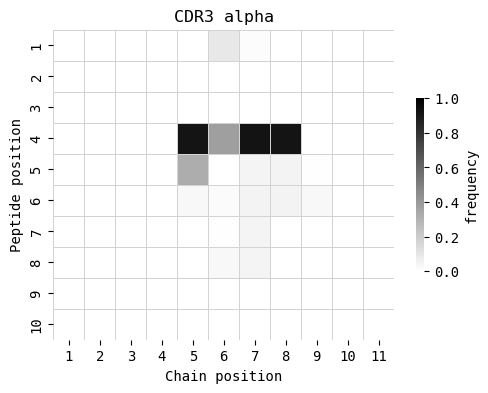


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


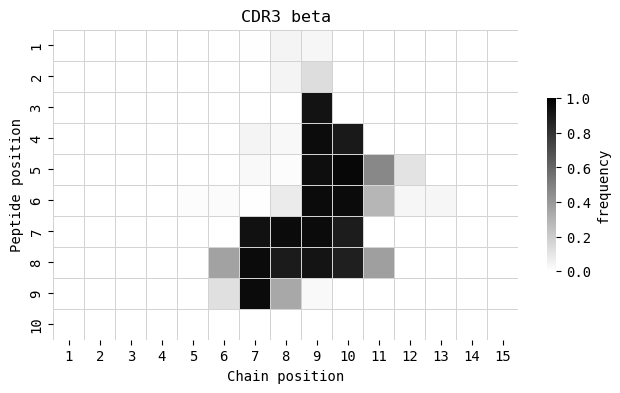


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


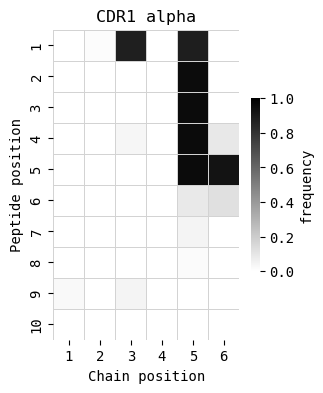


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


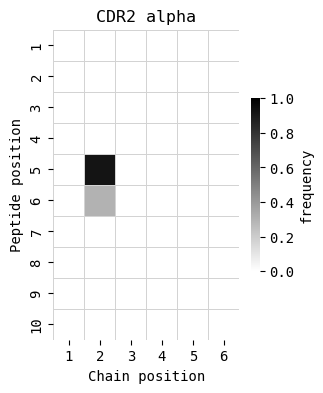


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


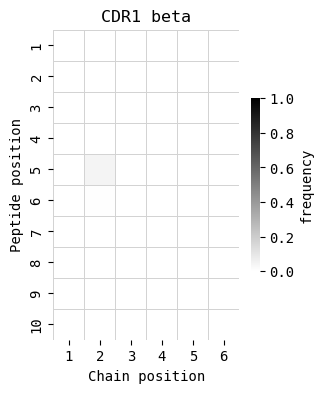


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


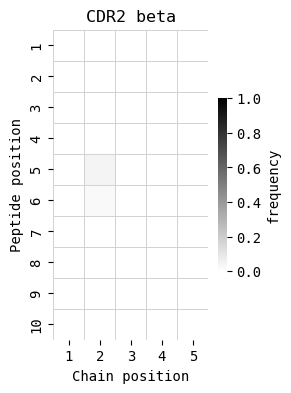


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


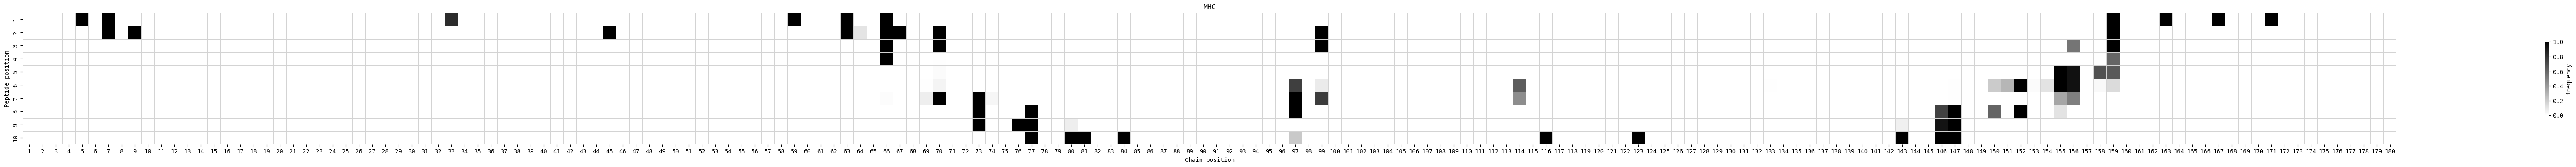

In [163]:
for chain in seq_dict.keys():
    plot_contacts_heatmap(chain)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


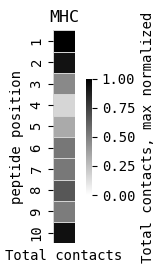

In [65]:
cur_chain = 'MHC'

cur_seq = seq_dict[cur_chain]
chain_start = start_dicts[cur_chain]
contacts_cur = res_df_native_exploded_to_write[res_df_native_exploded_to_write.chain_to == cur_chain]
contacts_cur['aa_num_to_adj'] = contacts_cur.aa_num_to - chain_start

contacts_cur['contacting_pair'] = contacts_cur.aa_num_from.apply(str) + '-' + contacts_cur.aa_num_to_adj.apply(str)

contacts_freq = contacts_cur.contacting_pair.value_counts()

contacts_df = pd.DataFrame(contacts_freq).reset_index()

contacts_df.contacting_pair = contacts_df.contacting_pair.str.split('-').apply(lambda x: [int(x[0]), int(x[1])])
contacts_df['num_from'] = contacts_df.contacting_pair.apply(lambda x: int(x[0]))
contacts_df['num_to'] = contacts_df.contacting_pair.apply(lambda x: int(x[1]))

contacts_df.contacting_pair = contacts_df.contacting_pair.apply(tuple)

array_from = list(range(1, 10))
array_to = list(range(1, len(cur_seq)+1))
pairs = list(itertools.product(array_from, array_to))

existing_contacts = set(contacts_df.contacting_pair)
noncontacting_pairs = []
for pair in set(pairs).difference(existing_contacts):
    noncontacting_pairs.append({
        'contacting_pair': pair,
        'count': 0,
        'num_from': pair[0],
        'num_to': pair[1]
    })

res_df = pd.concat([contacts_df, pd.DataFrame(noncontacting_pairs)])

pivoted_df = res_df.pivot(index='num_to', columns='num_from', values='count')

pivoted_df = pivoted_df

plt.figure(figsize=(1/2, len(index_peptides[0])/2))
sns.heatmap(pd.DataFrame(pivoted_df.sum())/pivoted_df.sum().max(),
            cbar_kws={'label': 'Total contacts, max normalized','pad': 0.3, 'shrink': 3},
            square=True,
            cmap='gray_r', linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1
           )
#ax.set_xlabel('peptide position')
#ax.set_ylabel('Chain position')

#ax.set_title(cur_chain.replace("_", " "))
plt.ylabel('peptide position')
plt.xlabel('Total contacts')
plt.xticks([], [])
plt.title(cur_chain.replace("_", " "))
plt.show()

# Entropy

In [67]:
cpl_data = data_cpl.T
cpl_data

position,1,2,3,4,5,6,7,8,9,10
residue,,,,,,,,,,
A,519.6,1142.4,1783.2,890.4,1.200000e+02,62.4,32.4,398.4,1056.0,12.0
C,58.8,88.8,133.2,134.4,-9.600000e+00,63.6,61.2,75.6,140.4,160.8
D,68.4,52.8,102.0,-38.4,-1.705300e-14,-2.4,12.0,37.2,58.8,80.4
E,85.2,80.4,525.6,-15.6,4.680000e+01,-4.8,31.2,28.8,10.8,100.8
F,2091.6,590.4,-32.4,44.4,4.200000e+01,934.8,108.0,110.4,226.8,78.0
G,746.4,814.8,88.8,1725.6,1.308000e+02,1599.6,134.4,272.4,90.0,398.4
H,948.0,139.2,6.0,69.6,5.640000e+01,98.4,54.0,199.2,50.4,62.4
I,1092.0,710.4,157.2,75.6,1.719600e+03,39.6,1465.2,1486.8,786.0,1521.6
K,88.8,354.0,-4.8,94.8,1.152000e+02,192.0,92.4,1267.2,1392.0,136.8


DataFrame.applymap has been deprecated. Use DataFrame.map instead.
DataFrame.applymap has been deprecated. Use DataFrame.map instead.


Text(-23.02777777777778, 0.5, 'Peptide position')

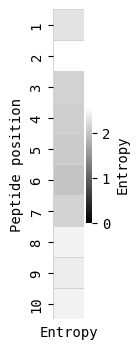

In [68]:
cpl_data = cpl_data.applymap(lambda x: 0 if x < 0 else x)

p_cpl = cpl_data / cpl_data.sum()
entropy = p_cpl.applymap(lambda x: -x*np.log(x) if x > 0 else 0).sum()


plt.figure(figsize=(1/2, 9/2))

sns.heatmap(pd.DataFrame(entropy), cbar_kws={'label': 'Entropy','shrink': 0.5}, square=True,cbar=True, vmin=0, cmap='gray', linewidths=0.5, linecolor='lightgray')
plt.xlabel('Entropy')
plt.xticks([], [])
plt.ylabel('Peptide position')

# Original peptide

In [142]:
data_cpl

residue,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
position,,,,,,,,,,,,,,,,,,,,
1,519.6,58.8,6.840000e+01,85.2,2091.6,746.4,948.0,1092.0,88.8,1591.2,1700.4,157.2,-49.2,0.0,-13.2,202.8,188.4,81.6,451.2,106.8
2,1142.4,88.8,5.280000e+01,80.4,590.4,814.8,139.2,710.4,354.0,1287.6,246.0,55.2,206.4,1039.2,97.2,886.8,1556.4,807.6,162.0,55.2
3,1783.2,133.2,1.020000e+02,525.6,-32.4,88.8,6.0,157.2,-4.8,307.2,46.8,138.0,373.2,1.2,50.4,1000.8,1671.6,12.0,762.0,12.0
4,890.4,134.4,-3.840000e+01,-15.6,44.4,1725.6,69.6,75.6,94.8,198.0,56.4,108.0,748.8,55.2,150.0,208.8,55.2,103.2,-4.8,75.6
5,120.0,-9.6,-1.705300e-14,46.8,42.0,130.8,56.4,1719.6,115.2,518.4,199.2,78.0,69.6,66.0,78.0,74.4,231.6,13.2,91.2,92.4
6,62.4,63.6,-2.400000e+00,-4.8,934.8,1599.6,98.4,39.6,192.0,44.4,30.0,56.4,294.0,76.8,102.0,127.2,15.6,18.0,756.0,1.2
7,32.4,61.2,1.200000e+01,31.2,108.0,134.4,54.0,1465.2,92.4,358.8,157.2,6.0,102.0,60.0,92.4,110.4,142.8,1322.4,28.8,409.2
8,398.4,75.6,3.720000e+01,28.8,110.4,272.4,199.2,1486.8,1267.2,751.2,1148.4,28.8,-9.6,22.8,214.8,283.2,224.4,1441.2,538.8,849.6
9,1056.0,140.4,5.880000e+01,10.8,226.8,90.0,50.4,786.0,1392.0,88.8,68.4,52.8,1405.2,94.8,1021.2,385.2,819.6,1323.6,85.2,21.6


In [90]:
index_peptides

['ALWGPDPAAA']

In [143]:
index_pept = 'ELAGIGILTV'
i = 1

res_dict = {}

for _, pos in data_cpl.iterrows():
    
    res_dict[i] = pos[index_pept[i-1]]/pos.max()
    i += 1

In [144]:
res_ser = pd.Series(res_dict)
res_ser = res_ser.apply(lambda x: 0 if x <0 else x)
res_ser

1     0.040734
2     0.827294
3     1.000000
4     1.000000
5     1.000000
6     1.000000
7     1.000000
8     0.505246
9     0.583262
10    0.728707
dtype: float64

In [145]:
index_pept

'ELAGIGILTV'

Text(-23.02777777777778, 0.5, 'Peptide position')

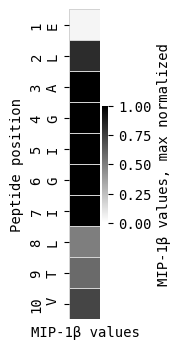

In [146]:
plt.figure(figsize=(1/2, 10/2))
#EAAGIGILTV
sns.heatmap(pd.DataFrame(res_ser), cbar_kws={'label': 'MIP-1β values, max normalized','shrink': 0.5}, square=True,cbar=True, vmin=0, cmap='gray_r', linewidths=0.5, linecolor='lightgray')
plt.xlabel('MIP-1β values')
plt.xticks([], [])
plt.yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5][::-1], ['10\nV', '9\nT', '8\nL', '7\nI', '6\nG', '5\nI', '4\nG', '3\nA', '2\nL', '1\nE'])
plt.ylabel('Peptide position')

# Worst peptide contacts

In [120]:
res_list = []
tcr_mhc_list = []

for peptide in tqdm.tqdm(os.listdir('/projects/structures/peptide_swap_mel5_worst/')):
    
    seq_dict = {
        'CAVNVAGKSTF': 'CDR3_alpha',
        'CAWSETGLGTGELFF': 'CDR3_beta',
        cdr1a: 'CDR1_alpha',
        cdr2a: 'CDR2_alpha',
        cdr1b: 'CDR1_beta',
        cdr2b: 'CDR2_beta',
        mhc_seq: 'MHC',
        peptide: 'peptide'
    }
    
    pdb_path = f'/projects/structures/peptide_swap_mel5_worst/{peptide}/{peptide}_pmhc_oc/ranked_0.pdb'
    if os.path.exists(pdb_path):
        coords_ca, coords_all, atom_to_ca_map = extract_coords_from_pdb_by_dict(pdb_path, seq_dict)

        coords_ca = apply_pca(coords_ca, pca)

        atomic_contacts, num_drawn_connections, num_nonredundant_contacts = plot_combined_residue_graph_pca(coords_ca,
                                                                                                    coords_all,
                                                                                                    atom_to_ca_map,
                                                                                                    max_distance=5.0,)

        res_df_i = get_peptides_contacts(atomic_contacts)
        res_df_i['peptide'] = peptide
        res_df_i['pdb_path'] = pdb_path
        res_df_i = add_abscent_contacts(res_df_i)
        res_df_i = res_df_i[['chain_from', 'aa_from', 'aa_num_from', 'peptide', 'pdb_path', 'contacts']]

        res_list.append(res_df_i)
        
        tcr_mhc_contacts = get_tcr_mhc_contacts(atomic_contacts)
        tcr_mhc_contacts['peptide'] = peptide
        tcr_mhc_contacts['pdb_path'] = pdb_path
        tcr_mhc_list.append(tcr_mhc_contacts)
        
    else:
        print(pdb_path)

  0%|          | 1/325 [00:03<20:02,  3.71s/it]X does not have valid feature names, but PCA was fitted with feature names


/projects/structures/peptide_swap_mel5_worst/CLFGPFFKVV/CLFGPFFKVV_pmhc_oc/ranked_0.pdb


  1%|          | 3/325 [00:07<12:25,  2.31s/it]X does not have valid feature names, but PCA was fitted with feature names


/projects/structures/peptide_swap_mel5_worst/RMWGPFFKVI/RMWGPFFKVI_pmhc_oc/ranked_0.pdb


  2%|▏         | 5/325 [00:11<11:30,  2.16s/it]X does not have valid feature names, but PCA was fitted with feature names


...

/projects/structures/peptide_swap_mel5_worst/CIWGPFWKVV/CIWGPFWKVV_pmhc_oc/ranked_0.pdb


X does not have valid feature names, but PCA was fitted with feature names
 97%|█████████▋| 316/325 [10:20<00:12,  1.34s/it]X does not have valid feature names, but PCA was fitted with feature names


/projects/structures/peptide_swap_mel5_worst/CMWGPFWPVV/CMWGPFWPVV_pmhc_oc/ranked_0.pdb
/projects/structures/peptide_swap_mel5_worst/CLFGPDWPVI/CLFGPDWPVI_pmhc_oc/ranked_0.pdb
/projects/structures/peptide_swap_mel5_worst/RMWGPFWKVI/RMWGPFWKVI_pmhc_oc/ranked_0.pdb


100%|██████████| 325/325 [10:39<00:00,  1.97s/it]

/projects/structures/peptide_swap_mel5_worst/CIWGPFWPVV/CIWGPFWPVV_pmhc_oc/ranked_0.pdb


In [131]:
res_df_worst = pd.concat(res_list)
res_df_worst

,chain_from,aa_from,aa_num_from,peptide,pdb_path,contacts
1,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR1_alpha, S, 30), (MHC, T, 163), (CDR1_alp..."
2,peptide,I,2,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"{(MHC, Y, 7), (MHC, H, 70), (MHC, Y, 99), (MHC..."
3,peptide,F,3,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"{(MHC, Q, 155), (MHC, H, 70), (MHC, Y, 99), (M..."
0,peptide,E,4,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR1_alpha, S, 30), (CDR1_alpha, G, 29), (CD..."
4,peptide,C,5,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR3_beta, G, 99), (MHC, Q, 155), (CDR1_alph..."
...,...,...,...,...,...,...
5,peptide,D,6,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR3_beta, G, 99), (MHC, T, 73), (CDR3_beta,..."
7,peptide,D,7,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR3_beta, G, 99), (MHC, T, 73), (CDR3_beta,..."
8,peptide,P,8,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"{(CDR3_beta, G, 99), (MHC, T, 73), (CDR3_beta,..."
6,peptide,V,9,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"{(MHC, T, 73), (CDR3_beta, L, 98), (CDR3_beta,..."


In [132]:
res_df_native = res_df_worst
res_df_worst.dropna(inplace = True)
res_df_native.index = list(range(len(res_df_native)))
res_df_native.contacts = res_df_native.contacts.apply(lambda x: list(x))
res_df_native_exploded_worst = res_df_native.explode('contacts')
res_df_native_exploded_worst['chain_to'] = res_df_native_exploded_worst.contacts.apply(lambda x: x[0])
res_df_native_exploded_worst['aa_to'] = res_df_native_exploded_worst.contacts.apply(lambda x: x[1])
res_df_native_exploded_worst['aa_num_to'] = res_df_native_exploded_worst.contacts.apply(lambda x: x[2])

res_df_native_exploded_worst

,chain_from,aa_from,aa_num_from,peptide,pdb_path,contacts,chain_to,aa_to,aa_num_to
0,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"(CDR1_alpha, S, 30)",CDR1_alpha,S,30
0,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, T, 163)",MHC,T,163
0,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"(CDR1_alpha, D, 27)",CDR1_alpha,D,27
0,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, Y, 7)",MHC,Y,7
0,peptide,R,1,RIFECEDQVA,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, Y, 171)",MHC,Y,171
...,...,...,...,...,...,...,...,...,...
1639,peptide,P,10,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, Y, 116)",MHC,Y,116
1639,peptide,P,10,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, D, 77)",MHC,D,77
1639,peptide,P,10,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, K, 146)",MHC,K,146
1639,peptide,P,10,RIFDDDDPVP,/projects/structures/peptide_swap_mel5_worst/R...,"(MHC, W, 147)",MHC,W,147


In [133]:
len(res_df_native_exploded_worst.pdb_path.unique())

164

In [134]:
contacts_for_tcren = res_df_native_exploded_to_write[res_df_native_exploded_to_write.chain_to != 'MHC']
contacts_for_tcren_worst = res_df_native_exploded_worst[res_df_native_exploded_worst.chain_to != 'MHC']

tcren_potentials = pd.read_csv('/home/dluppov/tcren-ms/tcren_potentials_mine.csv')

In [135]:
contacts_for_tcren['tcren_potential'] = np.nan
contacts_for_tcren_worst['tcren_potential'] = np.nan

for i, contact in contacts_for_tcren.iterrows():
    
    potential = tcren_potentials[(tcren_potentials['residue.aa.from'] == contact.aa_to) & (tcren_potentials['residue.aa.to'] == contact.aa_from)].TCRen.iloc[0]
    
    #rand_aa = random_amino_acid()
    
    #potential_rand = tcren_potentials[(tcren_potentials['residue.aa.from'] == contact.aa_to) & (tcren_potentials['residue.aa.to'] == rand_aa)].TCRen.iloc[0]
    
    contacts_for_tcren.loc[i, 'tcren_potential'] = potential

for i, contact in contacts_for_tcren_worst.iterrows():
    potential = tcren_potentials[(tcren_potentials['residue.aa.from'] == contact.aa_to) & (tcren_potentials['residue.aa.to'] == contact.aa_from)].TCRen.iloc[0]

    #rand_aa = random_amino_acid()

    #potential_rand = tcren_potentials[(tcren_potentials['residue.aa.from'] == contact.aa_to) & (tcren_potentials['residue.aa.to'] == rand_aa)].TCRen.iloc[0]

    contacts_for_tcren_worst.loc[i, 'tcren_potential'] = potential


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [136]:
tcren_res = contacts_for_tcren.groupby('peptide').tcren_potential.sum()
tcren_res_worst = contacts_for_tcren_worst.groupby('peptide').tcren_potential.sum()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



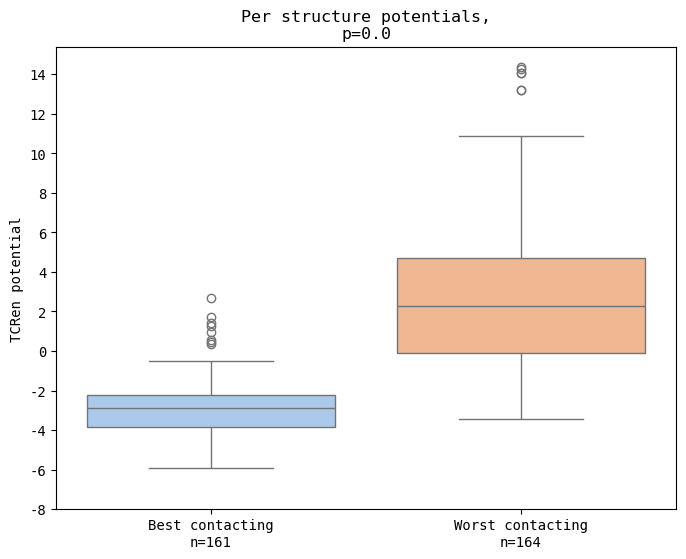

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind


# Assuming your lists are named 'original' and 'generated'
# Replace these with your actual lists
original = list(tcren_res)  # Example data
generated = list(tcren_res_worst)  # Example data

data = pd.DataFrame({
    'value': original + generated,
    'category': [f'Best contacting\nn={len(original)}'] * len(original) + [f'Worst contacting\nn={len(generated)}'] * len(generated)
})

# Create the plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='category', y='value', palette='pastel')
#plt.title('Original vs Bootstrapped')
plt.xlabel('')
plt.ylabel('TCRen potential')
plt.yticks(list(range(-8, 16)[::2]), list(range(-8, 16)[::2]))
p_val = round(mannwhitneyu(original, generated,).pvalue, 5)

plt.title(f'Per structure potentials,\np={p_val}')

plt.show()

# Logos

([<matplotlib.axis.XTick at 0x7f3428662610>,
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10')])

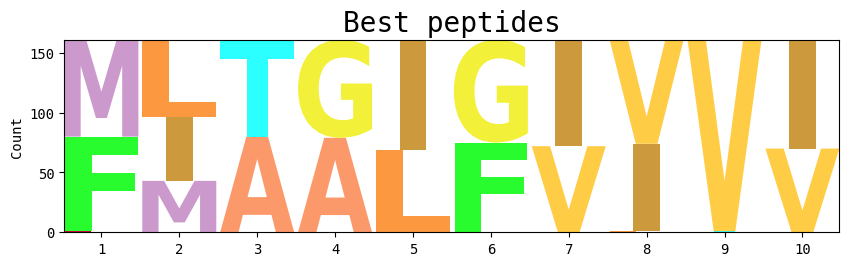

In [128]:
import logomaker
clones = list(tcren_res.index)
mat_df = logomaker.alignment_to_matrix(clones)
logomaker.Logo(mat_df, color_scheme='skylign_protein')
plt.title('Best peptides', fontsize=20)
plt.ylabel('Count')
plt.xticks(list(range(0, 10)), list(range(1, 11)))

([<matplotlib.axis.XTick at 0x7f341e2c96d0>,
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10')])

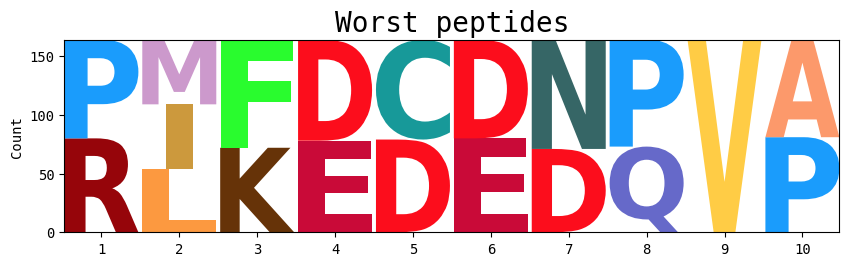

In [108]:
clones = list(tcren_res_worst.index)
mat_df = logomaker.alignment_to_matrix(clones)
logomaker.Logo(mat_df, color_scheme='skylign_protein')
plt.title('Worst peptides', fontsize=20)
plt.ylabel('Count')
plt.xticks(list(range(0, 10)), list(range(1, 11)))

In [109]:
tcren_res_worst

peptide
PIFDCDNPVP    -0.501048
PIFDCENPVA    -2.109259
PIFDDDDQVA     8.633473
PIFDDEDPVP    -1.334027
PIFDDENPVA    -0.053067
                ...    
RMKECDNPVP     2.761195
RMKECEDPVP     2.389292
RMKECENPVP     1.578164
RMKEDDDPVP     3.317691
RMKEDDNPVP    12.093943
Name: tcren_potential, Length: 164, dtype: float64